In [12]:
# ── Imports ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm
from scipy.spatial import cKDTree
from scipy.stats import wasserstein_distance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Install torch_geometric and its dependencies if not already present
try:
    import torch_geometric
except ImportError:
    print("torch_geometric not found, installing...")
    TORCH_VERSION = torch.__version__.split('+')[0]
    if torch.cuda.is_available():
        CUDA_VERSION = torch.version.cuda.replace('.', '')
        !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+cu{CUDA_VERSION}.html
    else:
        !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+cpu.html
    print("torch_geometric installed.")
    # Re-import after installation
    import torch_geometric

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyG version : {torch_geometric.__version__}")

Using device: cpu
PyG version : 2.7.0


In [13]:
# ── Load raw images into RAM ───────────────────────────────
print("Loading data into RAM...")
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    X_raw = f['X_jets'][:20000]
    y_raw = f['y'][:20000]
print(f"Loaded: {X_raw.shape} ✅")

# ── Build graphs ───────────────────────────────────────────
def build_graph(image, label, k=8, max_points=100):
    image = image.transpose(2, 0, 1).copy()
    for c in range(3):
        ch_max = image[c].max()
        if ch_max > 0:
            image[c] /= ch_max

    mask     = (image.sum(axis=0) > 0)
    eta, phi = np.where(mask)

    if len(eta) == 0:
        x          = np.zeros((1, 5), dtype=np.float32)
        edge_index = np.zeros((2, 0), dtype=np.int64)
    else:
        ecal   = image[0, eta, phi]
        hcal   = image[1, eta, phi]
        tracks = image[2, eta, phi]
        energy = ecal + hcal + tracks

        if len(energy) > max_points:
            top_idx        = np.argsort(energy)[-max_points:]
            eta, phi       = eta[top_idx], phi[top_idx]
            ecal, hcal, tracks = ecal[top_idx], hcal[top_idx], tracks[top_idx]

        eta_n = (eta / 124.0) * 2 - 1
        phi_n = (phi / 124.0) * 2 - 1
        x     = np.stack([eta_n, phi_n, ecal, hcal, tracks], axis=1).astype(np.float32)

        k_     = min(k, len(x) - 1)
        tree   = cKDTree(x[:, :2])
        _, idx = tree.query(x[:, :2], k=k_+1)
        idx    = idx[:, 1:]
        n      = len(x)
        row    = np.repeat(np.arange(n), k_)
        col    = idx.reshape(-1)
        edge_index = np.stack([row, col], axis=0).astype(np.int64)

    return Data(
        x          = torch.tensor(x,          dtype=torch.float32),
        edge_index = torch.tensor(edge_index, dtype=torch.long),
        y          = torch.tensor([int(label)],    dtype=torch.long)
    )

print("Building graphs...")
graph_list = []
for i in tqdm(range(len(X_raw))):
    graph_list.append(build_graph(X_raw[i], y_raw[i]))
print(f"Total graphs: {len(graph_list)} ✅")

Loading data into RAM...
Loaded: (20000, 125, 125, 3) ✅
Building graphs...


100%|██████████| 20000/20000 [00:24<00:00, 819.14it/s]

Total graphs: 20000 ✅


In [14]:
# ── Split & Dataloaders ────────────────────────────────────
train_size = int(0.8 * len(graph_list))
val_size   = len(graph_list) - train_size

train_graphs = graph_list[:train_size]
val_graphs   = graph_list[train_size:]

train_loader = GeoDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = GeoDataLoader(val_graphs,   batch_size=32, shuffle=False)

print(f"Train graphs : {len(train_graphs)}")
print(f"Val graphs   : {len(val_graphs)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train graphs : 16000
Val graphs   : 4000
Train batches: 500
Val batches  : 125


In [15]:
# ── Graph Transformer ──────────────────────────────────────
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=64, nhead=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Self attention + residual
        attn_out, _ = self.attn(x, x, x, key_padding_mask=mask)
        x = self.norm1(x + attn_out)
        # Feed forward + residual
        x = self.norm2(x + self.ff(x))
        return x

class JetGraphTransformer(nn.Module):
    def __init__(self, in_channels=5, d_model=64, nhead=4,
                 num_layers=4, num_points=100, dropout=0.1):
        super().__init__()
        self.num_points = num_points

        # Input projection
        self.input_proj = nn.Linear(in_channels, d_model)

        # Positional encoding (learnable)
        self.pos_enc = nn.Embedding(num_points, d_model)

        # Transformer encoder
        self.encoder = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dropout)
            for _ in range(num_layers)
        ])

        # Latent projection
        self.to_latent = nn.Linear(d_model, d_model)

        # Decoder — generate point cloud from latent
        self.decoder = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dropout)
            for _ in range(num_layers)
        ])

        # Output projection
        self.output_proj = nn.Linear(d_model, in_channels)

    def encode(self, x, padding_mask=None):
        # x: (B, N, 5)
        B, N, _ = x.shape
        pos  = torch.arange(N, device=x.device).unsqueeze(0).expand(B, -1)
        x    = self.input_proj(x) + self.pos_enc(pos)
        for layer in self.encoder:
            x = layer(x, padding_mask)
        # Mean pool to get latent
        if padding_mask is not None:
            mask  = (~padding_mask).float().unsqueeze(-1)
            z     = (x * mask).sum(1) / mask.sum(1)
        else:
            z = x.mean(dim=1)
        return self.to_latent(z), x

    def decode(self, z, enc_out, padding_mask=None):
        # Use encoder output as decoder input (autoencoder style)
        x = enc_out
        for layer in self.decoder:
            x = layer(x, padding_mask)
        return self.output_proj(x)

    def forward(self, x, padding_mask=None):
        z, enc_out = self.encode(x, padding_mask)
        recon      = self.decode(z, enc_out, padding_mask)
        return recon, z

# ── Init ───────────────────────────────────────────────────
model     = JetGraphTransformer(in_channels=5, d_model=64, nhead=4,
                                 num_layers=4, num_points=100).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized ✅")
print(f"Total parameters: {total_params:,}")

Model initialized ✅
Total parameters: 411,141


In [16]:
# ── Pad graphs to fixed size for Transformer ───────────────
def prepare_batch(batch, max_nodes=100, device='cpu'):
    """
    Convert PyG batch into padded tensor for Transformer
    Returns:
        x_padded     : (B, max_nodes, 5)
        padding_mask : (B, max_nodes) — True = padded (ignore)
    """
    counts  = torch.bincount(batch.batch)
    B       = len(counts)
    x_padded = torch.zeros(B, max_nodes, 5)
    padding_mask = torch.ones(B, max_nodes, dtype=torch.bool)  # True = ignore

    start = 0
    for i, count in enumerate(counts):
        count = count.item()
        nodes = batch.x[start:start+count]
        n     = min(count, max_nodes)
        x_padded[i, :n, :]     = nodes[:n]
        padding_mask[i, :n]    = False  # valid nodes
        start += count

    return x_padded.to(device), padding_mask.to(device)

# ── Loss ───────────────────────────────────────────────────
def transformer_loss(recon, target, padding_mask):
    # Only compute loss on valid (non-padded) nodes
    mask = (~padding_mask).float().unsqueeze(-1)  # (B, N, 1)
    loss = ((recon - target) ** 2 * mask).sum() / mask.sum()
    return loss

# ── Test ───────────────────────────────────────────────────
batch = next(iter(train_loader))
x_pad, pad_mask = prepare_batch(batch, max_nodes=100, device=device)
print(f"Padded input shape  : {x_pad.shape}")
print(f"Padding mask shape  : {pad_mask.shape}")
print(f"Valid nodes example : {(~pad_mask[0]).sum().item()}")

Padded input shape  : torch.Size([32, 100, 5])
Padding mask shape  : torch.Size([32, 100])
Valid nodes example : 100


In [17]:
# ── Training Loop ──────────────────────────────────────────
EPOCHS = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]")
    for batch in pbar:
        batch = batch.to(device)
        x_pad, pad_mask = prepare_batch(batch, max_nodes=100, device=device)

        optimizer.zero_grad()
        recon, z = model(x_pad, pad_mask)
        loss     = transformer_loss(recon, x_pad, pad_mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ── Validate ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]  "):
            batch = batch.to(device)
            x_pad, pad_mask = prepare_batch(batch, max_nodes=100, device=device)
            recon, z = model(x_pad, pad_mask)
            loss     = transformer_loss(recon, x_pad, pad_mask)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ml4sci-falcon/transformer_best.pth')

    print(f"✅ Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val_loss:.4f}\n")

print("Training complete ✅")

Epoch 01/30 [Val]  : 100%|██████████| 125/125 [00:32<00:00,  3.81it/s]


✅ Epoch 01 | Train: 0.1147 | Val: 0.0073 | Best: 0.0073



Epoch 02/30 [Val]  : 100%|██████████| 125/125 [00:32<00:00,  3.83it/s]


✅ Epoch 02 | Train: 0.0157 | Val: 0.0034 | Best: 0.0034



Epoch 03/30 [Val]  : 100%|██████████| 125/125 [00:32<00:00,  3.83it/s]


...

✅ Epoch 28 | Train: 0.0003 | Val: 0.0000 | Best: 0.0000



Epoch 29/30 [Val]  : 100%|██████████| 125/125 [00:32<00:00,  3.85it/s]


✅ Epoch 29 | Train: 0.0003 | Val: 0.0001 | Best: 0.0000



Epoch 30/30 [Val]  : 100%|██████████| 125/125 [00:32<00:00,  3.83it/s]

✅ Epoch 30 | Train: 0.0003 | Val: 0.0000 | Best: 0.0000

Training complete ✅


In [18]:
# ── Load best model ────────────────────────────────────────
model.load_state_dict(torch.load('/content/drive/MyDrive/ml4sci-falcon/transformer_best.pth'))
model.eval()

# ── Collect predictions ────────────────────────────────────
all_recon, all_targets, all_z, all_labels = [], [], [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        batch = batch.to(device)
        x_pad, pad_mask = prepare_batch(batch, max_nodes=100, device=device)
        recon, z = model(x_pad, pad_mask)
        all_recon.append(recon.cpu())
        all_targets.append(x_pad.cpu())
        all_z.append(z.cpu())
        all_labels.append(batch.y.view(-1).cpu())

all_recon   = torch.cat(all_recon).numpy()
all_targets = torch.cat(all_targets).numpy()
all_z       = torch.cat(all_z).numpy()
all_labels  = torch.cat(all_labels).numpy()

# ── Metrics ────────────────────────────────────────────────
mse  = np.mean((all_recon - all_targets) ** 2)
wass = np.mean([wasserstein_distance(
                all_targets[i, :, 2],
                all_recon[i, :, 2]) for i in range(len(all_recon))])

print(f"{'Metric':<20} {'Value':>10}")
print(f"{'-'*32}")
print(f"{'MSE':<20} {mse:>10.6f}")
print(f"{'Wasserstein':<20} {wass:>10.6f}")

Evaluating: 100%|██████████| 125/125 [00:37<00:00,  3.32it/s]

Metric                    Value
--------------------------------
MSE                    0.000009
Wasserstein            0.001355


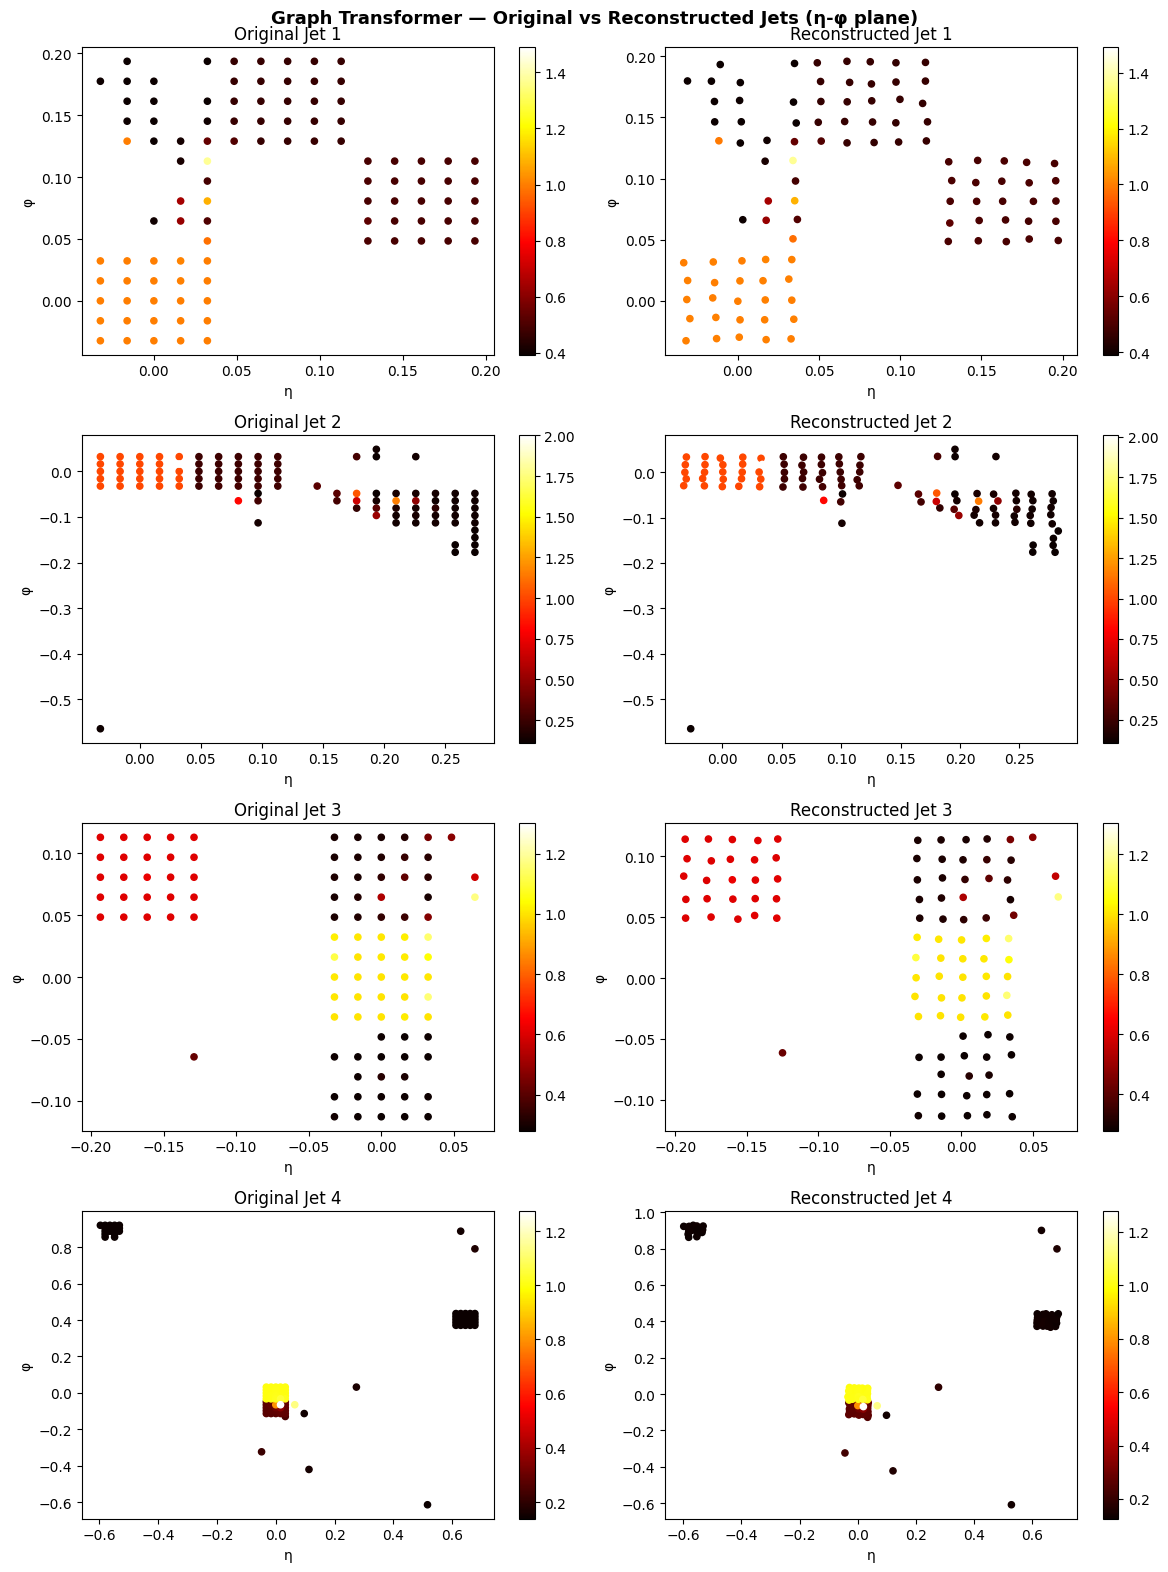

Saved ✅


In [19]:
# ── Side-by-Side Point Cloud Visualization ────────────────
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle('Graph Transformer — Original vs Reconstructed Jets (η-φ plane)',
             fontsize=13, fontweight='bold')

for i in range(4):
    orig  = all_targets[i]   # (100, 5)
    recon = all_recon[i]     # (100, 5)

    # Filter non-padded points (non-zero)
    orig_mask  = orig[:, 2:].sum(axis=1)  > 0
    recon_mask = recon[:, 2:].sum(axis=1) > 0

    # Original
    sc1 = axes[i, 0].scatter(orig[orig_mask, 0], orig[orig_mask, 1],
                              c=orig[orig_mask, 2] + orig[orig_mask, 3] + orig[orig_mask, 4],
                              cmap='hot', s=20)
    axes[i, 0].set_title(f'Original Jet {i+1}')
    axes[i, 0].set_xlabel('η')
    axes[i, 0].set_ylabel('φ')
    plt.colorbar(sc1, ax=axes[i, 0])

    # Reconstructed
    sc2 = axes[i, 1].scatter(recon[recon_mask, 0], recon[recon_mask, 1],
                              c=recon[recon_mask, 2] + recon[recon_mask, 3] + recon[recon_mask, 4],
                              cmap='hot', s=20)
    axes[i, 1].set_title(f'Reconstructed Jet {i+1}')
    axes[i, 1].set_xlabel('η')
    axes[i, 1].set_ylabel('φ')
    plt.colorbar(sc2, ax=axes[i, 1])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/transformer_reconstructions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

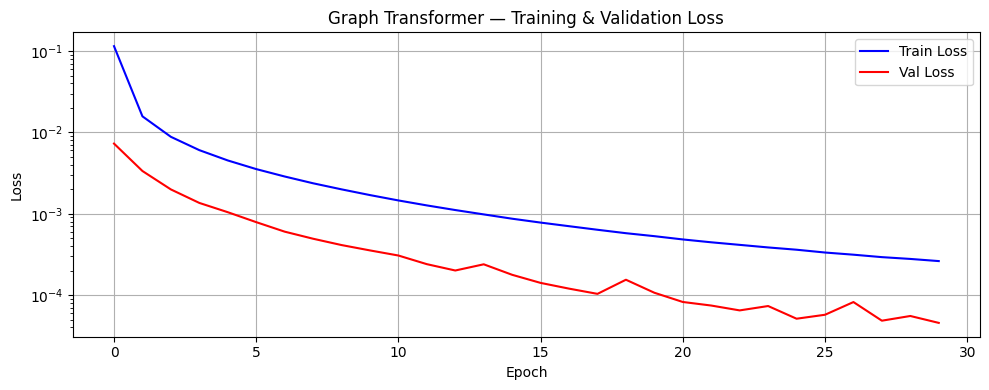

In [20]:
# ── Loss Curve ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='blue')
ax.plot(val_losses,   label='Val Loss',   color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Graph Transformer — Training & Validation Loss')
ax.set_yscale('log')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Running t-SNE...


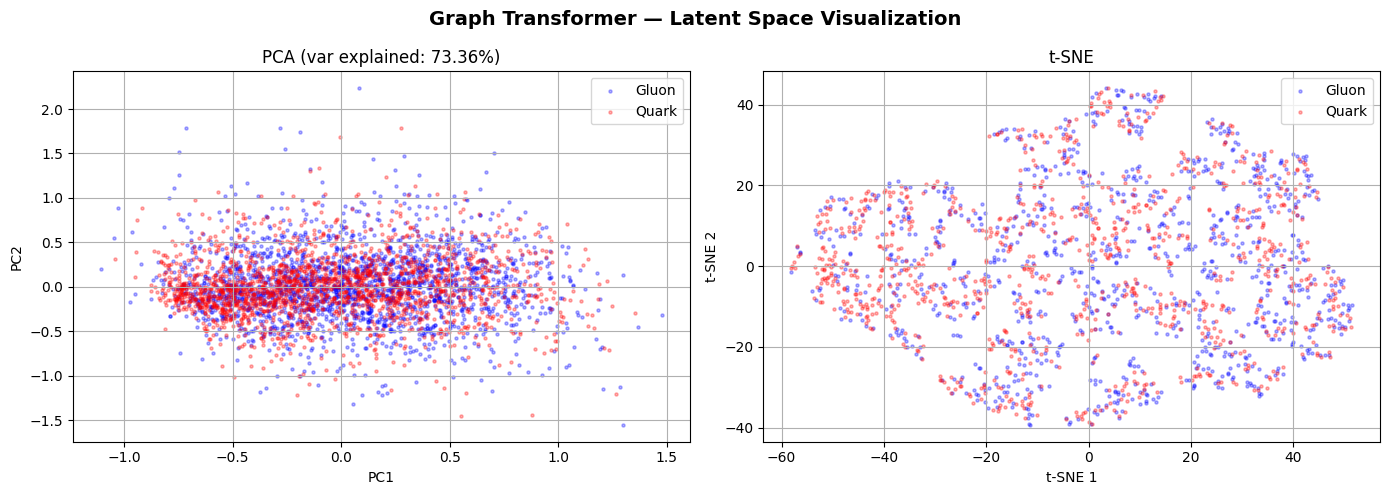

Saved ✅


In [21]:
# ── Latent Space Visualization ─────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph Transformer — Latent Space Visualization', fontsize=14, fontweight='bold')

# ── PCA ───────────────────────────────────────────────────
pca   = PCA(n_components=2)
z_pca = pca.fit_transform(all_z)
axes[0].scatter(z_pca[all_labels==0, 0], z_pca[all_labels==0, 1],
                c='blue', alpha=0.3, s=5, label='Gluon')
axes[0].scatter(z_pca[all_labels==1, 0], z_pca[all_labels==1, 1],
                c='red',  alpha=0.3, s=5, label='Quark')
axes[0].set_title(f'PCA (var explained: {pca.explained_variance_ratio_.sum():.2%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# ── t-SNE ─────────────────────────────────────────────────
print("Running t-SNE...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42)
z_tsne = tsne.fit_transform(all_z[:2000])
axes[1].scatter(z_tsne[all_labels[:2000]==0, 0], z_tsne[all_labels[:2000]==0, 1],
                c='blue', alpha=0.3, s=5, label='Gluon')
axes[1].scatter(z_tsne[all_labels[:2000]==1, 0], z_tsne[all_labels[:2000]==1, 1],
                c='red',  alpha=0.3, s=5, label='Quark')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/transformer_latent_space.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")